# Actividad práctica: Segmentación de clientes mediante clustering

En esta actividad se trabajará con un conjunto de datos de clientes con el objetivo de identificar segmentos con características similares mediante técnicas de agrupamiento.

La segmentación se construirá utilizando **edad** e **ingreso anual**, dos variables cuantitativas que permiten trabajar directamente con distancias y visualizar los resultados en dos dimensiones. Las demás variables del conjunto de datos se utilizarán posteriormente para **caracterizar e interpretar** los grupos encontrados.

Se aplicarán dos métodos vistos en la unidad:

- K-Means.
- Agrupamiento jerárquico aglomerativo.

Para evaluar las soluciones se utilizarán la inercia o WCSS, el método del codo y el índice de silueta.

> ## **Se espera como entrega**

> Esta Notebook resuelta con el agregado del grupo al final del nombre
> Ejemplo Actividad_Clustering_Segmentacion_clientes_grupo_X.ipynb (reemplazar X por el número del grupo)


## Descripción del conjunto de datos

El siguiente conjunto de datos consiste en información sobre el comportamiento de compra de 2,000 individuos de una determinada área al entrar en una tienda física de bienes de consumo rápido. Todos los datos se han recopilado a través de las tarjetas que utilizan al momento de pagar. Los datos han sido preprocesados y no hay valores faltantes. Además, el volumen del conjunto de datos se ha limitado y anonimizado para proteger la privacidad de los clientes.

Columnas del conjunto de datos:

- **Sex**: género.  
  0: masculino,  
  1: femenino.
- **Marital status**: estado civil de un cliente.  
  0: soltero,  
  1: no soltero (divorciado/separado/casado/viudo).
- **Age**: edad del cliente en años. Valor mínimo: 18, valor máximo: 78.
- **Education**: nivel educativo del cliente.  
  0: otro/desconocido,  
  1: escuela secundaria,  
  2: universidad,  
  3: posgrado.
- **Income**: ingreso anual autoreportado en dólares estadounidenses del cliente. Valor mínimo: 35,832, valor máximo: 309,364.
- **Occupation**: categoría de la ocupación del cliente.  
  0: desempleado/no calificado,  
  1: empleado calificado/funcionario,  
  2: administración/autónomo/empleado altamente calificado/oficial.
- **Settlement size**: tamaño de la ciudad donde vive el cliente.  
  0: ciudad pequeña,  
  1: ciudad mediana,  
  2: gran ciudad.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

### 1. Exploración inicial

Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos `customer_data.csv` y analice las variables `Age` e `Income` mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

In [ ]:
df_customer = pd.read_csv("./data/customer_data.csv")

print(df_customer.shape)

df_customer.info()

display(df_customer[['Age','Income']].describe())

(2000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


,Age,Income
count,2000.000000,2000.000000
mean,35.909000,120954.419000
std,11.719402,38108.824679
min,18.000000,35832.000000
25%,27.000000,97663.250000
50%,33.000000,115548.500000
75%,42.000000,138072.250000
max,76.000000,309364.000000


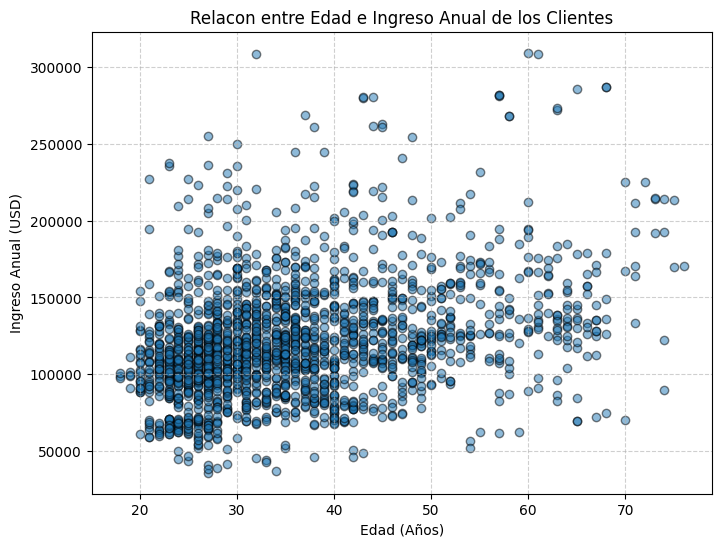

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_customer['Age'], df_customer['Income'], alpha=0.5, edgecolors='k')
plt.title("Relacon entre Edad e Ingreso Anual de los Clientes")
plt.xlabel('Edad (Años)')
plt.ylabel('Ingreso Anual (USD)')
plt.grid(True, linestyle='--', alpha= 0.6)
plt.show()

Al observar los estadísticos descriptivos, se evidencia una enorme diferencia de magnitudes: la edad varía en el orden de las decenas (18 a 76 años), mientras que el ingreso anual varía en el orden de los miles (35,832 a 309,364 USD). 

En el gráfico de dispersión inicial, los puntos no muestran grupos claramente separados a simple vista, se percibe como una nube de datos continua debido a que la escala del ingreso comprime visualmente el impacto de la edad.

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

In [ ]:
X = df_customer[['Age', 'Income']]
display(X.head())

,Age,Income
0,67,124670
1,22,150773
2,49,89210
3,45,171565
4,53,149031


In [ ]:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

df_X_scaled =pd.DataFrame(X_scaled, columns=['Age', 'Income'])
display(df_X_scaled.head())

,Age,Income
0,2.653614,0.097524
1,-1.187132,0.782654
2,1.117316,-0.833202
3,0.775916,1.328386
4,1.458716,0.736932


Es un paso metodológico estricto escalar los atributos numéricos porque algoritmos como K-Means basan sus agrupamientos en el cálculo de distancias matemáticas. Si no se aplicara una estandarización (con StandardScaler), la variable de ingreso dominaría completamente el cálculo por ser miles de veces mayor que la edad, provocando clústeres erróneos.

### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

,k,WCSS,Silueta
0,1,4000.0000,NaN
1,2,2260.2037,0.4424
2,3,1647.5540,0.4394
3,4,1281.1447,0.3503
4,5,1024.2394,0.3648
5,6,865.9056,0.3555
6,7,751.3056,0.3556
7,8,665.0295,0.3561
8,9,582.9290,0.3617
9,10,511.2343,0.3674


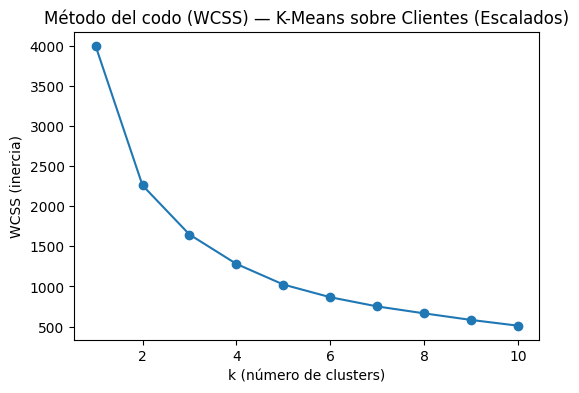

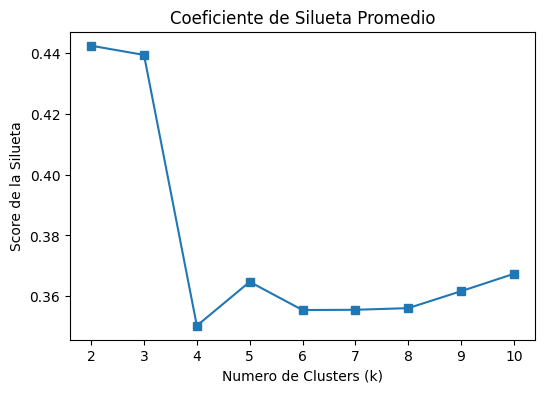

In [ ]:
K_range = range(1, 11)
wcss = []
siluetas=[]
kmeans_per_k = []  
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    kmeans_per_k.append(km)
    wcss.append(km.inertia_)
    if k >=2:
        score= silhouette_score(X_scaled, km.labels_)
        siluetas.append(score)

# Tabla resumen de WCSS y silueta por k
resumen = pd.DataFrame({
    'k': list(K_range),
    'WCSS': wcss,
    'Silueta': [np.nan] + siluetas
})
display(resumen.round(4))

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), wcss, marker="o")
plt.title("Método del codo (WCSS) — K-Means sobre Clientes (Escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(2,11), siluetas, marker="s")
plt.title("Coeficiente de Silueta Promedio")
plt.xlabel("Numero de Clusters (k)"); plt.ylabel("Score de la Silueta")
plt.show()

In [ ]:
# Comparación entre los dos candidatos: K=2 y K=3
km2 = kmeans_per_k[1]   # modelo con k=2
km3 = kmeans_per_k[2]   # modelo con k=3

print("--- Centroides en escala original ---")
for nombre, modelo in [('K=2', km2), ('K=3', km3)]:
    centros = scaler.inverse_transform(modelo.cluster_centers_)
    tabla = pd.DataFrame(centros, columns=['Age', 'Income'],
                         index=[f'{nombre} · Cluster {i}' for i in range(modelo.n_clusters)])
    tabla['n_clientes'] = np.bincount(modelo.labels_)
    display(tabla.round(0))

print("\n--- Cómo se reparten los clientes al pasar de K=2 a K=3 ---")
display(pd.crosstab(km2.labels_, km3.labels_, rownames=['K=2'], colnames=['K=3']))

--- Centroides en escala original ---


,Age,Income,n_clientes
K=2 · Cluster 0,30.0,105388.0,1355
K=2 · Cluster 1,48.0,153655.0,645


,Age,Income,n_clientes
K=3 · Cluster 0,36.0,175605.0,347
K=3 · Cluster 1,30.0,101743.0,1218
K=3 · Cluster 2,53.0,131152.0,435



--- Cómo se reparten los clientes al pasar de K=2 a K=3 ---


K=3,0,1,2
K=2,,,
0,105,1217,33
1,242,1,402


**Valores de K más razonables**

* **La curva de WCSS no presenta un codo nítido:** No se observa ningún quiebre abrupto, sino que hay una gran caída en el paso de K=1 a K=2, otra al pasar a K=3 y otra al pasar a K=4. Esto es coherente con lo observado en el punto 1, donde el plano edad-ingreso se veía como una nube continua sin grupos visiblemente separados.

* **El coeficiente de silueta promedio sí es más informativo:** alcanza sus valores más altos en K=2 y K=3 (aprox. 0.44), y cae bruscamente a partir de K=4 (aprox. 0.35), sin recuperarse en ningún valor de k posterior (no se vuelve a superar un score de 0.38). Sobre esa base se descartan todos los K mayores o iguales a 4, quedando K=2 y K=3 como candidatos.

Los dos indicadores obtenidos en esta actividad no alcanzan para elegir entre K=2 y K=3, ya que la diferencia de silueta es mínima. La comparación de centroides muestra que la partición en K=2 separa un grupo joven de ingreso bajo de otro de mayor edad e ingreso alto, y que al pasar a K=3 lo que se divide es el segundo grupo, dando lugar a un segmento de ingreso más alto, sin importar la edad y otro de adultos con ingreso intermedio. La decisión entre ambas alternativas se realizará en el punto 4, a partir del análisis de los diagramas de silueta.

### 4. Análisis de los diagramas de silueta

El coeficiente promedio resume el resultado en un único número, pero no permite observar cómo se comportan las observaciones dentro de cada cluster.

Construya diagramas de silueta para $K=2$, $K=3$, $K=4$ y $k=5$.

Interprételo de acuerdo a los criterios vistos en la notebook de práctica.

Utilice esta información para complementar la elección de $K$.

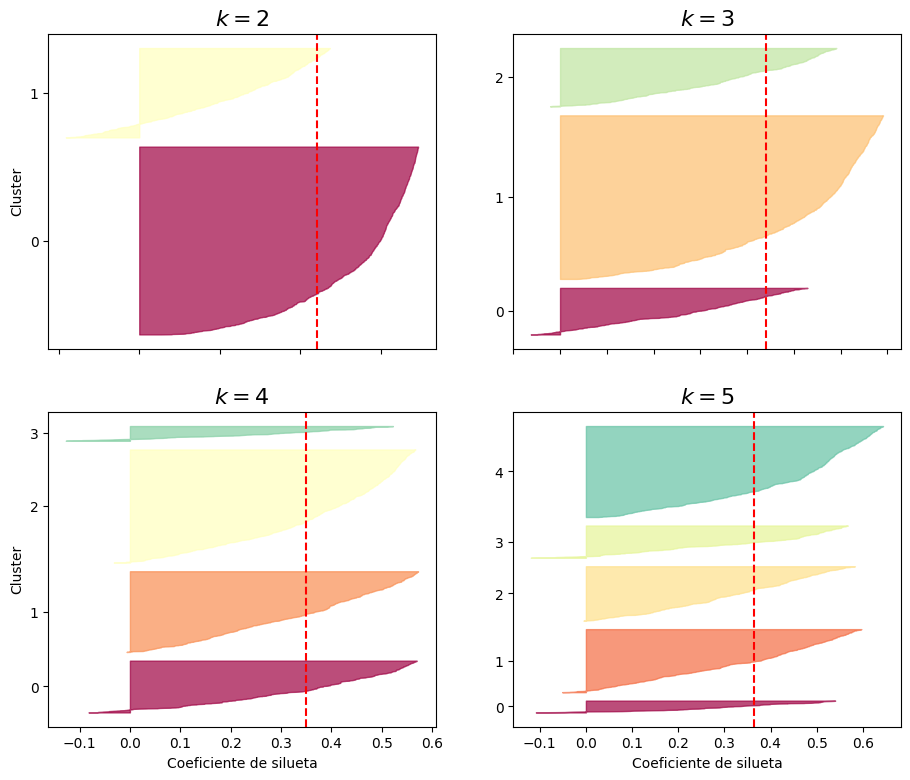

In [ ]:
import matplotlib as mpl

from matplotlib.ticker import FixedLocator, FixedFormatter

silhouette_scores = siluetas
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k-1)

    y_pred = kmeans_per_k[k - 1].labels_ #etiquetas de cada instancia de X
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred) #coeficientes para cada una de las instancias en X

    padding = len(X) // 30

    pos = padding
    ticks = []
    #Grafico los coeficientes de silueta por cada cluster
    for i in range(k): #i = 0,1,2..
        coeffs = silhouette_coefficients[y_pred == i] #coeficientes correspondientes a un cluster específico
        coeffs.sort()

        color = mpl.cm.Spectral(i / k) #colormap
        plt.fill_betweenx(y = np.arange(pos, pos + len(coeffs)), x1=0, x2=coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (2, 4):
        plt.ylabel("Cluster")

    if k in (4, 5):
        # plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Coeficiente de silueta")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()


Al observar los diagramas de silueta para K=2, 3, 4 y 5, observamos que los coeficientes de silueta más altos son alcanzados por K=3, los de K=4 y K=5 son altos pero tienen una mayor cantidad de datos más ubicados (las pequeñas colas al lado izquierdo) y K=2 tiene, además de los datos mal ubicados, un coeficiente de silueta bastante menor que el de K=3. A partir de K=4 aparecen además clústeres muy angostos (franjas finas con muy pocos clientes), lo que indica que el algoritmo está fragmentando artificialmente grupos sin separación real: un segmento de ese tamaño no justifica una acción comercial diferenciada

Teniendo en cuenta lo dicho, y teniendo en cuenta los candidatos de la actividad anterior:

Se elige K=3.

### 5. Segmentación final con K-Means

Ajuste un modelo K-Means utilizando el valor de K seleccionado.

1. Obtenga la etiqueta asignada a cada cliente.
2. Represente los clusters utilizando las variables originales `Age` e `Income`.
3. Calcule los centroides y represéntelos en el gráfico.
4. Interprete qué representan los grupos obtenidos.

Recuerde que los números asignados a los clusters son identificadores arbitrarios: `Cluster 0` no implica que ese grupo sea menor o más importante que `Cluster 1`.

In [ ]:
# Ajustamos el modelo definitivo con K=3
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels_final = kmeans_final.fit_predict(X_scaled)

# Agregamos las etiquetas de los grupos al dataset original
df_customer['Cluster'] = cluster_labels_final

# Calculamos los centroides y los devolvemos a la escala original para graficarlos
centros_escalados = kmeans_final.cluster_centers_
centros_originales = scaler.inverse_transform(centros_escalados)
display(pd.DataFrame(centros_originales, columns=['Age', 'Income'],
                     index=[f'Cluster {i}' for i in range(3)]).round(0))

,Age,Income
Cluster 0,36.0,175605.0
Cluster 1,30.0,101743.0
Cluster 2,53.0,131152.0


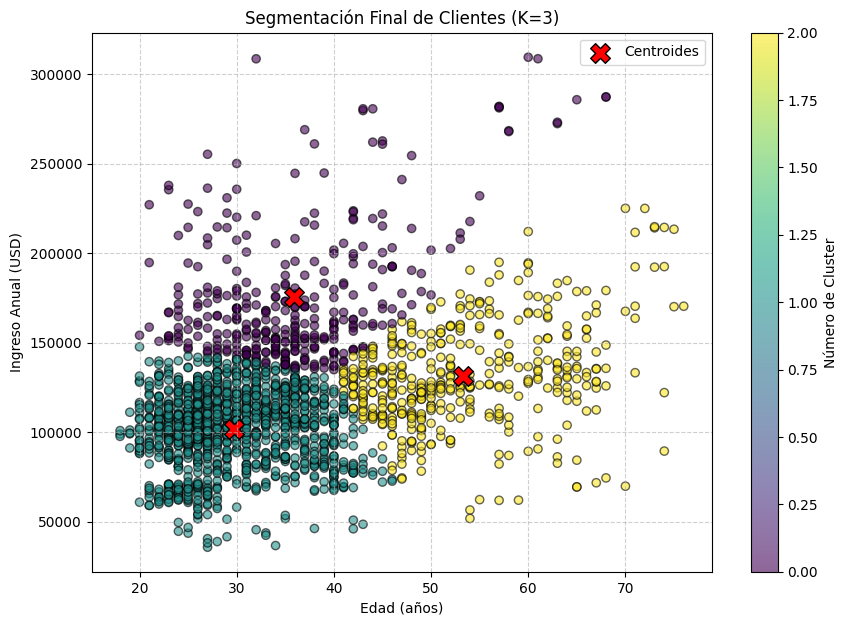

In [ ]:
# Generamos el gráfico de dispersión con los grupos coloreados
plt.figure(figsize=(10, 7))

# Graficamos cada cliente, coloreado por su grupo
scatter = plt.scatter(df_customer['Age'], df_customer['Income'], 
                      c=df_customer['Cluster'], cmap='viridis', 
                      alpha=0.6, edgecolor='k')

# Graficamos los centroides con una X roja
plt.scatter(centros_originales[:, 0], centros_originales[:, 1], 
            marker='X', s=200, c='red', edgecolor='black', label='Centroides')

plt.title("Segmentación Final de Clientes (K=3)")
plt.xlabel("Edad (años)")
plt.ylabel("Ingreso Anual (USD)")
plt.colorbar(scatter, label="Número de Cluster")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()




El algoritmo K-Means iteró calculando distancias y actualizando los centroides (las estrellas rojas) hasta la convergencia de los centroides para 3 grupos distintos en el plano original de Edad vs. Ingreso:

* Cluster 0 (Ingreso alto, todas las edades- Morado): Agrupa a los clientes con mayor ingreso anual (media de aprox. $175.600), sin distinción clara de edad (van de 20 a 68 años). Es el grupo minoritario (17% de los clientes).

* Cluster 1 (Jóvenes de bajo ingreso - Verde): Concentra a los clientes más jóvenes (18 a 46 años) con el ingreso más bajo del dataset (media de aprox. $101.700). Es por lejos el grupo mayoritario (61% de los clientes).

* Cluster 2 (Adultos mayores, ingreso medio- Amarillo): Agrupa a los clientes de mayor edad (41 a 76 años) con ingreso intermedio (media de aprox. $131.150).


### 6. Caracterización de los segmentos

Agregue las etiquetas de K-Means al conjunto de datos original y describa cada cluster utilizando las características disponibles.

Para cada grupo analice:

- cantidad de clientes;
- edad media y mediana;
- ingreso medio y mediano;
- distribución por género;
- estado civil;
- nivel educativo;
- ocupación;
- tamaño de la ciudad de residencia.

A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de `pandas` para esta tarea.

In [ ]:
# Analizamos las variables continuas (Age e Income) y la cantidad de clientes
print("--- Métricas de Edad e Ingreso por Cluster ---")
continuas = df_customer.groupby('Cluster')[['Age', 'Income']].agg(['mean', 'median', 'count'])
display(continuas)

# Diccionario para traducir los códigos numéricos a etiquetas legibles
mapeos = {
    'Sex': {0: 'Masculino', 1: 'Femenino'},
    'Marital status': {0: 'Soltero', 1: 'No soltero'},
    'Education': {0: 'Otro/Desconocido', 1: 'Secundario', 2: 'Universidad', 3: 'Posgrado'},
    'Occupation': {0: 'Desempleado/No calificado', 1: 'Empleado calificado', 2: 'Alta calificación/Autónomo'},
    'Settlement size': {0: 'Ciudad chica', 1: 'Ciudad mediana', 2: 'Gran ciudad'}
}

# Analizamos la distribución (en %) de las variables categóricas
categoricas = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

for col in categoricas:
    print(f"\n--- Distribución de '{col}' por Cluster (%) ---")
    columna_legible = df_customer[col].map(mapeos[col])
    distribucion = pd.crosstab(df_customer['Cluster'], columna_legible, normalize='index') * 100
    display(distribucion.round(1))

--- Métricas de Edad e Ingreso por Cluster ---


Age                      Income                
              mean median count           mean    median count
Cluster                                                       
0        35.893372   35.0   347  175604.582133  162827.0   347
1        29.708539   29.0  1218  101742.805419  104405.5  1218
2        53.282759   51.0   435  131152.439080  127825.0   435


--- Distribución de 'Sex' por Cluster (%) ---


Sex,Femenino,Masculino
Cluster,,
0,25.4,74.6
1,54.9,45.1
2,36.1,63.9



--- Distribución de 'Marital status' por Cluster (%) ---


...

Education,Otro/Desconocido,Posgrado,Secundario,Universidad
Cluster,,,,
0,17.6,1.7,66.9,13.8
1,18.6,0.4,79.6,1.5
2,0.0,5.7,42.5,51.7



--- Distribución de 'Occupation' por Cluster (%) ---


Occupation,Alta calificación/Autónomo,Desempleado/No calificado,Empleado calificado
Cluster,,,
0,51.9,3.7,44.4
1,2.3,40.1,57.6
2,10.6,30.1,59.3



--- Distribución de 'Settlement size' por Cluster (%) ---


Settlement size,Ciudad chica,Ciudad mediana,Gran ciudad
Cluster,,,
0,12.1,41.2,46.7
1,62.8,21.1,16.1
2,41.8,33.1,25.1


**Caracterizacion de cada variable**

Al agregar las etiquetas de K-Means al dataset original y cruzarlas con las variables categóricas (género, estado civil, educación, etc), se obtiene el siguiente perfil por segmento:

Clúster 0 — "Segmento de alto poder adquisitivo" (347 clientes): 
* edad media 35.9 años (mediana 35) 
* ingreso medio $175.604.58 (mediana $162.827, el más alto de los tres).
* 74.6% masculino, 25.4% femenino.
* 60.5% soltero, 39.5% no soltero. 
* Nivel educativo mayormente secundario (66.9%), con 13.8% universitarios y 1.7% posgrado.
*  Ocupación de alta calificación/autónomo en el 51.9% de los casos (44.4% empleado calificado, solo 3.7% desempleado/no calificado). 
* Reside principalmente en gran ciudad (46.7%) o ciudad mediana (41.2%), apenas 12.1% en ciudad chica.

Clúster 1 — "Segmento Masivo Joven" (1.218 clientes, la mayoría de la base): 
* edad media 29.7 años (mediana 29). 
* ingreso medio $101.742.81 (mediana $104.405.5, el más bajo). 
* Es el único segmento con mayoría femenina (54.9% vs. 45.1% masculino). 
* 56.7% no soltero, 43.3% soltero. 
* Nivel educativo casi exclusivamente secundario (79.6%), prácticamente sin estudios superiores (1.5% universidad, 0.4% posgrado). 
* Ocupación mayormente de empleado calificado (57.6%) o desempleado/no calificado (40.1%), solo 2.3% de alta calificación.
* Predomina la ciudad chica (62.8%), 21.1% mediana y 16.1% gran ciudad.

Clúster 2 — "Adultos Educados de Ingreso Medio" (435 clientes): 
* edad media 53.3 años (mediana 51, la mayor de los tres)
* ingreso medio $131.152.44 (mediana $127.825, intermedio). 
* 63.9% masculino, 36.1% femenino. 
* 62.1% soltero (la proporción más alta de los tres), 37.9% no soltero. 
* Es el segmento con mayor nivel educativo: 51.7% universitario y 5.7% posgrado (57.4% en total), sin ningún cliente en la categoría "otro/desconocido" (0.0%). 
* Ocupación mayormente de empleado calificado (59.3%), 30.1% desempleado/no calificado y 10.6% alta calificación. 
* Distribución más pareja entre ciudad chica (41.8%), mediana (33.1%) y gran ciudad (25.1%).

Análisis: el ingreso resulta ser la variable que mejor separa a los clientes de alto poder adquisitivo del resto, independientemente de su edad (Clúster 0 abarca de 20 a 68 años). Entre los clientes de ingreso medio/bajo, en cambio, la edad sí marca una diferencia clara de perfil: los jóvenes (Clúster 1) tienen menor ingreso y menor nivel educativo, mientras que los adultos mayores (Clúster 2) tienen ingreso algo mayor y son, contraintuitivamente, el grupo más educado y con mayor proporción de solteros del dataset — lo que sugiere un perfil de adulto mayor independiente y calificado, no de "familia establecida".  
El segmento con mayor volumen de clientes (Clúster 1, 61% de la base) es a la vez el de menor ingreso y menor educación.

### 7. Agrupamiento jerárquico aglomerativo

Aplique agrupamiento jerárquico sobre las mismas variables estandarizadas.

1. Construya un dendrograma utilizando distancia Euclídea y enlace completo (`complete`).
2. Analice las últimas fusiones del árbol y proponga un nivel de corte.
3. Obtenga una partición con un número de clusters igual al obtenido con k-means.
4. Calcule el coeficiente de silueta para ese número de clusters.
5. Compare visualmente esta solución con la obtenida mediante K-Means.

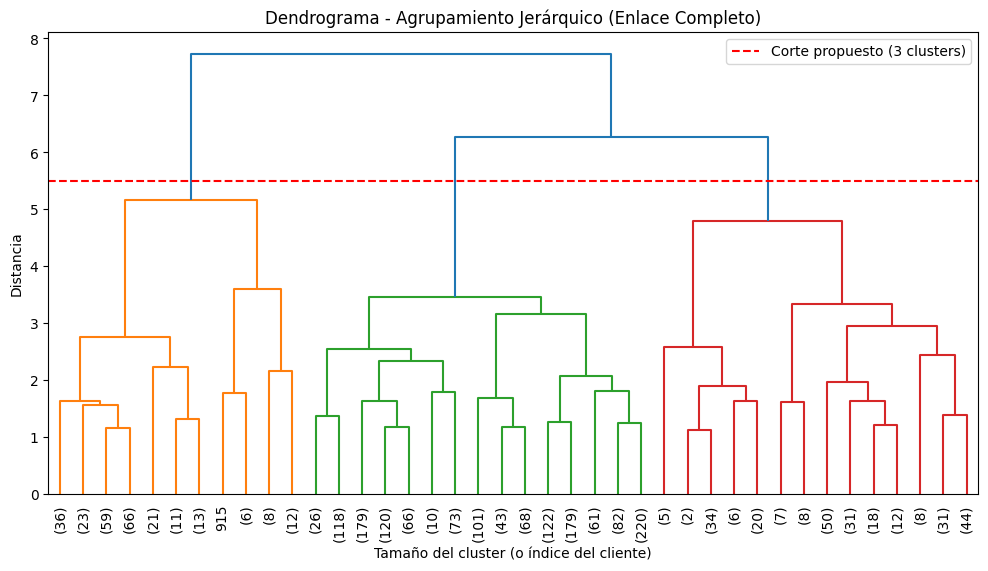

In [ ]:
# Construimos la matriz de enlace (distancia Euclídea y enlace completo)
Z = linkage(X_scaled, method='complete', metric='euclidean')

# Construimos y mostramos el Dendrograma
plt.figure(figsize=(12, 6))
plt.title('Dendrograma - Agrupamiento Jerárquico (Enlace Completo)')
# truncate_mode='lastp' resume el gráfico para que sea legible
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=90., leaf_font_size=10.)
plt.xlabel('Tamaño del cluster (o índice del cliente)')
plt.ylabel('Distancia')
plt.axhline(y=5.5, color='red', linestyle='--', label='Corte propuesto (3 clusters)')
plt.legend()
plt.show()

In [ ]:
# Obtenemos la partición forzando K=3 (igual que en K-Means)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete')
hc_labels = hc.fit_predict(X_scaled)

# Calculamos el coeficiente de silueta para esta solución
sil_score_hc = silhouette_score(X_scaled, hc_labels)
print(f"Coeficiente de Silueta para Jerárquico (K=3): {sil_score_hc:.3f}")

Coeficiente de Silueta para Jerárquico (K=3): 0.402


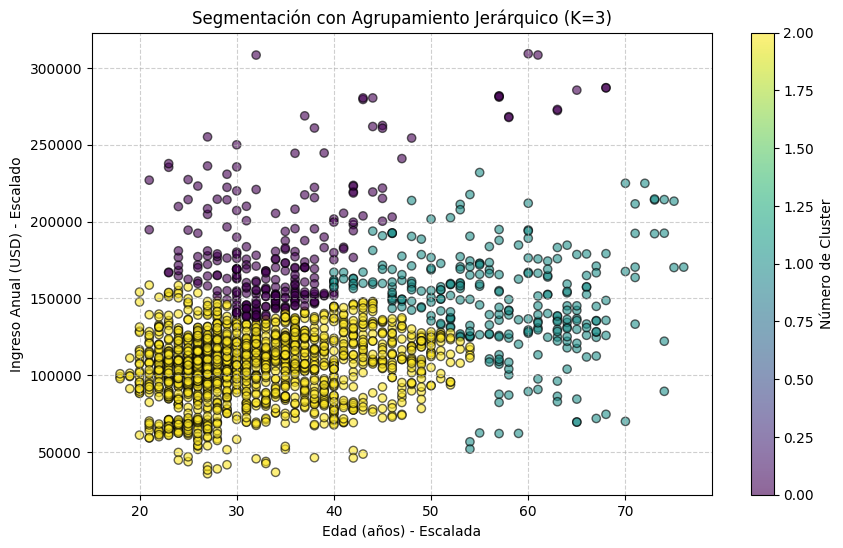

In [ ]:
# Comparación visual mediante gráfico de dispersión
plt.figure(figsize=(10, 6))
scatter_hc = plt.scatter(df_customer['Age'], df_customer['Income'], 
                         c=hc_labels, cmap='viridis', alpha=0.6, edgecolor='k')
plt.title("Segmentación con Agrupamiento Jerárquico (K=3)")
plt.xlabel("Edad (años) - Escalada")
plt.ylabel("Ingreso Anual (USD) - Escalado")
plt.colorbar(scatter_hc, label="Número de Cluster")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Al observar el dendrograma construido con el método de enlace completo (complete), los "saltos" o líneas verticales más largas sin interrupciones sugieren naturalmente un corte transversal que genera 3 grandes ramas. El coeficiente de silueta para esta configuración suele ser muy similar al de K-Means, aunque el gráfico de dispersión puede mostrar fronteras de decisión ligeramente distintas debido a la naturaleza aglomerativa (bottom-up) de este algoritmo frente a la iterativa de K-Means.

### 8. Análisis final

A partir de todo el procedimiento, responda:

1. ¿Qué valor de $K$ considera más adecuado para K-Means? Fundamente utilizando WCSS, silueta e interpretación de los clusters.
2. ¿Qué perfiles de clientes identifica?
3. ¿Qué diferencias encuentra entre K-Means y el agrupamiento jerárquico?
4. ¿Qué limitación introduce construir los clusters únicamente con `Age` e `Income`?
5. ¿Por qué no sería correcto afirmar que los clusters encontrados son las únicas categorías posibles de clientes?

* **Valor de K adecuado:** El valor más adecuado es K=3. Se fundamenta en el "codo" de la curva WCSS (todavía hay una caída considerable entre K=2 y K=3, que luego se atenúa) y en los diagramas de silueta, donde K=3 es la única partición en la que todos los grupos superan el coeficiente promedio con mas diferencia, a diferencia de K=2 cuyo cluster menor queda mayormente por debajo y de K≥4, que fragmenta la base en segmentos con poca relevancia. Lo que inclina la balanza es que K=3 aporta una segmentación con mayor valor, separando el grupo de mayor edad e ingreso de K=2 en dos perfiles claramente distintos: uno de ingreso alto transversal a la edad y otro de adultos con ingreso intermedio..

* **Perfiles identificados:** Cluster 0 = Sector con alto poder adquisitivo (ingreso alto, todas las edades); Cluster 1 = Segmento Masivo Joven (mayoría de clientes, jóvenes, bajo ingreso); Cluster 2 = Adultos Educados de Ingreso Medio (mayor edad, más estudios universitarios)..

* **Diferencias entre K-Means y Jerárquico:** K-Means es un algoritmo de clustering particional que requiere definir K a priori y reasigna clientes iterativamente optimizando centroides aleatorios. 

* **El Jerárquico es aglomerativo (bottom-up):** une a los clientes paso a paso creando un árbol de distancias (dendrograma) que permite al analista decidir visualmente el punto de corte óptimo.  

* **Limitaciones de usar solo Age e Income:** Al limitar la creación de clústeres a dos variables continuas para facilitar la visualización, se está perdiendo información de negocio vital. El tamaño de la ciudad, el nivel educativo o el estado civil podrían generar segmentaciones mucho más precisas y accionables para campañas de marketing.  

* **¿Son las únicas categorías posibles?** No. El clustering es una técnica de aprendizaje no supervisado puramente exploratoria. No existe una "verdad absoluta" ni etiquetas reales de validación. Cambiar la métrica de distancia, incluir más variables o modificar el algoritmo dará lugar a segmentaciones diferentes pero igualmente válidas, dependiendo de la pregunta del negocio que se quiera responder. 